In [91]:
import glob as glob
import pandas as pd
import os

# load in a envelope
acoustics = '../../TS_acoustics'
envelopes = glob.glob(acoustics + '/env_*.csv')
print(envelopes)
example = 1
envtest = pd.read_csv(envelopes[example])
envtest.head()


['../../TS_acoustics\\env_103_203_12_1_20250113_152455_doughnut_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_13_1_20250113_152513_spinach_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_14_1_20250113_152536_balloon_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_15_1_20250113_152557_bacon_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_16_1_20250113_152613_chlorine_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_17_1_20250113_152643_leather_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_18_1_20250113_152657_pillow_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_19_1_20250113_152712_traffic_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_20_1_20250113_152735_bitter_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_21_1_20250113_152824_tiger_board.wav_norm.csv', '../../TS_acoustics\\env_103_203_23_1_20250113_152946_trumpet_ground.wav_norm.csv', '../../TS_acoustics\\env_103_203_24_1_20250113_152957_pasta_ground.wav_norm.csv', '../../

,time,audio,envelope,filename,envelope_norm,envelope_change
0,0.0,0.000000,0.000024,103_203_13_1_20250113_152513_spinach_board.wav,0.027902,-0.000030
1,2.0,0.000000,0.000026,103_203_13_1_20250113_152513_spinach_board.wav,0.028136,0.000034
2,4.0,-0.000064,0.000028,103_203_13_1_20250113_152513_spinach_board.wav,0.028369,0.000096
3,6.0,0.000012,0.000031,103_203_13_1_20250113_152513_spinach_board.wav,0.028595,0.000154
4,8.0,-0.000134,0.000033,103_203_13_1_20250113_152513_spinach_board.wav,0.028811,0.000208


In [92]:
# add gyroscope
gyroscope = '../../gyroscope.csv'
gyrotest = pd.read_csv(gyroscope)
gyrotest.head()

,group_name,trial_number,timing_source,time,AccX(g),AccY(g),AccZ(g),AsX(°/s),AsY(°/s),AsZ(°/s),...,AngleZ(°),HX(uT),HY(uT),HZ(uT),Q0(),Q1(),Q2(),Q3(),Temperature(°C),Battery level(%)
0,103_203,12,camera_start,2025-01-13T15:24:37.610,0.008,0.096,-0.969,9.949,-0.244,0.366,...,-127.29,-30.592,17.950,10.392,-0.01501,-0.44363,0.89548,0.03146,23.5,30
1,103_203,12,camera_start,2025-01-13T15:24:37.570,0.001,-0.030,-1.054,-1.526,0.000,-0.183,...,-127.25,-30.392,19.350,10.967,0.00153,-0.44403,0.89597,-0.00089,23.5,30
2,103_203,12,camera_start,2025-01-13T15:24:37.603,0.005,0.003,-0.969,-1.465,0.000,0.244,...,-127.25,-30.392,19.350,10.967,0.00153,-0.44403,0.89597,-0.00089,23.5,30
3,103_203,12,camera_start,2025-01-13T15:24:37.661,0.004,-0.023,-1.041,-3.723,0.000,0.000,...,-127.26,-30.475,23.283,12.342,0.00153,-0.44403,0.89597,-0.00089,23.5,30
4,103_203,12,camera_start,2025-01-13T15:24:37.721,-0.004,-0.015,-1.044,-15.869,0.183,-0.427,...,-127.25,-30.475,23.283,12.342,0.00153,-0.44403,0.89597,-0.00089,23.5,30


In [93]:

# 1. Clean off the "acoustics\" path so you only have "env_103_203_..."
clean_filename = os.path.basename(envelopes[example])

# 2. Now split the clean filename
parts = clean_filename.split('_')

# 3. Grab the correct pieces
pair = f"{parts[1]}_{parts[2]}"  # Combines '103' and '203'
trail_number = parts[3]           # Grabs '12'

print(f"Pair: {pair}")
print(f"Trail: {trail_number}")

gyrotest = gyrotest[(gyrotest['group_name'] == pair) & (gyrotest['trial_number'] == int(trail_number))]

# add metadata
meta = pd.read_csv('../../metadata.csv')
meta.head()
conditionbalance = meta['clue_giver_condition']



Pair: 103_203
Trail: 13


In [94]:
meta = meta[(meta['pair_id'] == pair) & (meta['trial_number'] == int(trail_number))]
meta.head()

,pair_id,participant_1_id,participant_2_id,session_date,trial_end_time,trial_number,clue_giver_id,clue_giver_condition,target_word,taboo_1,taboo_2,taboo_3,taboo_4,taboo_5,audio_file_name,video_clue_giver_cam01,video_clue_giver_cam02,video_guesser_cam01,video_guesser_cam02,textgrid_file_name
1,103_203,103,203,13/01/2025,13/01/2025 15:25,13,103,board,spinach,vegetable,eat,green,leafy,popeye,103_203_13_1_20250113_152513_spinach_board.wav,103_203_13_1_20250113_152513_spinach_board_clu...,103_203_13_1_20250113_152513_spinach_board_clu...,103_203_13_1_20250113_152513_spinach_board_gue...,103_203_13_1_20250113_152513_spinach_board_gue...,103_203_13_20250113_152513_spinach_board_p1.Te...


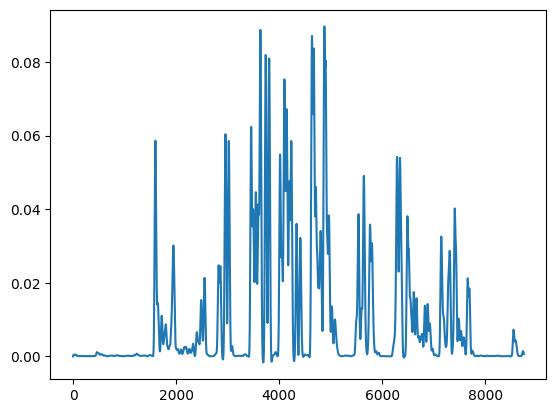

In [95]:
# plot  a single envelope
import matplotlib.pyplot as plt

# timeseries envelope
plt.plot(envtest['envelope_change'])

<Axes: xlabel='t'>

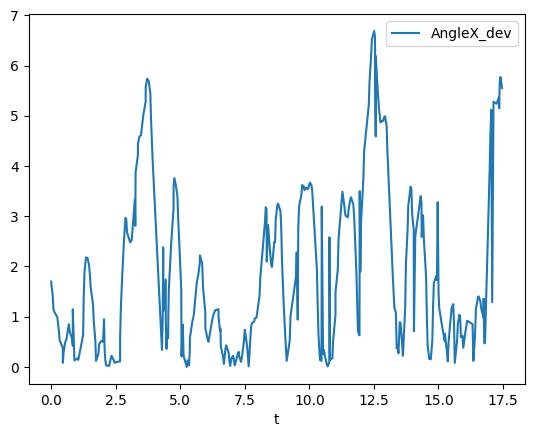

In [96]:
import numpy as np

g = gyrotest.copy()
g['t'] = (pd.to_datetime(g['time']) - pd.to_datetime(g['time']).iloc[0]).dt.total_seconds()
g = g.sort_values('t').reset_index(drop=True)      # MUST be time-ordered before unwrap

ang = g['AngleX(°)'].to_numpy()

# 1. unwrap: removes the ±180 jumps (np.unwrap works in radians)
ang_u = np.degrees(np.unwrap(np.radians(ang)))

# 2. recentre on resting posture (median = the upright baseline), then absolute deviation
ang_dev = np.abs(ang_u - np.median(ang_u))         # |lean away from centre|

g['AngleX_dev'] = ang_dev
g.plot(x='t', y='AngleX_dev')                       # should be smooth, no cliffs

# Load in gestures

In [97]:
# load + parse gesture data (if not already in memory)
gest = pd.read_csv('../../gestureclassifications/analysis/kinematic_features.csv')
ids = gest['gesture_id'].str.split('_', expand=True)
gest['pair']  = ids[0] + '_' + ids[1]
gest['trial'] = ids[2].astype(int)
# only keep cue-giver so any videos with guesser in name are out
gest = gest[gest['gesture_id'].str.contains('clueGiver')].copy()

In [98]:
# Check offset onset voicing/F0
import pandas as pd, numpy as np, glob, os

def voicing_segments(f0_path):
    """Onset/offset (seconds) of voiced stretches from an F0 file."""
    df = pd.read_csv(f0_path)
    t = df['time_ms'].to_numpy() / 1000.0           # ms -> s
    voiced = df['f0'].notna().to_numpy()            # F0 present = voiced
    # find rising/falling edges of the voiced boolean
    edges = np.diff(voiced.astype(int))
    onsets  = t[1:][edges == 1]
    offsets = t[1:][edges == -1]
    if voiced[0]:  onsets  = np.r_[t[0], onsets]     # starts voiced
    if voiced[-1]: offsets = np.r_[offsets, t[-1]]   # ends voiced
    return pd.DataFrame({'onset': onsets, 'offset': offsets})

# parse pair/trial from the f0 filename: f0_108_208_34_1_...
def parse_id(path):
    parts = os.path.basename(path).split('_')
    return f"{parts[1]}_{parts[2]}", int(parts[3])

f0_files = glob.glob('../../TS_acoustics/f0_*.csv')
voicing = []
for fp in f0_files:
    pair, trial = parse_id(fp)
    seg = voicing_segments(fp)
    seg['pair'], seg['trial'] = pair, trial
    voicing.append(seg)
voicing = pd.concat(voicing, ignore_index=True)

print(f"{voicing.groupby(['pair','trial']).ngroups} trials, "
      f"{len(voicing)} voiced segments total")
voicing.head()

80 trials, 2317 voiced segments total


,onset,offset,pair,trial
0,1.345010,1.377082,103_203,12
1,1.401136,1.623634,103_203,12
2,1.669737,1.735885,103_203,12
3,1.848137,2.034554,103_203,12
4,2.359281,2.507613,103_203,12


# Resampling gyroscope to match envelope sampling rate

In [99]:
import numpy as np
import pandas as pd
from scipy.ndimage import uniform_filter1d

def align_gyro_to_envelope(envtest, gyrotest, column='envelope', fs=500.0, smoothing_seconds=0.5):
    """Put speech envelope and gyro on one time grid; return (time, envelope, sway_speed, sway_lean).

    sway_speed = smoothed |angular speed|; sway_lean = smoothed |AngleX deviation from upright|.
    """
    # envelope onto a numeric time grid (seconds)
    envelope = envtest[column].to_numpy()
    envelope_time = envtest['time'].to_numpy().astype(float)
    if np.median(np.diff(envelope_time)) > 0.5:        # too big to be seconds -> ms
        envelope_time = envelope_time / 1000.0

    # gyro: order by time BEFORE unwrap/smooth (rows arrive unsorted)
    gyro = gyrotest.copy()
    gyro['seconds'] = (pd.to_datetime(gyro['time']) - pd.to_datetime(gyro['time']).iloc[0]).dt.total_seconds()
    gyro = gyro.sort_values('seconds').reset_index(drop=True)
    gyro_time = gyro['seconds'].to_numpy()

    angular_speed = gyro[next(c for c in gyro.columns if c.startswith('AsX'))].to_numpy()

    angle = gyro[next(c for c in gyro.columns if c.startswith('AngleX'))].to_numpy()
    angle_unwrapped = np.degrees(np.unwrap(np.radians(angle)))       # remove ±180 cliffs
    lean_angle = np.abs(angle_unwrapped - np.median(angle_unwrapped))

    # clip to overlapping span
    start = max(envelope_time[0], gyro_time[0])
    end   = min(envelope_time[-1], gyro_time[-1])
    keep = (envelope_time >= start) & (envelope_time <= end)
    time = envelope_time[keep]

    # resample gyro onto the envelope grid, smooth on that uniform grid
    window = max(1, int(smoothing_seconds * fs))
    sway_speed = uniform_filter1d(np.abs(np.interp(time, gyro_time, angular_speed)), window)
    sway_lean  = uniform_filter1d(       np.interp(time, gyro_time, lean_angle),      window)

    return time, envelope[keep], sway_speed, sway_lean

time, envelope_clipped, sway_speed, sway_lean = align_gyro_to_envelope(envtest, gyrotest)

9 gestures, 25 voiced segments (trial ends 17.5s)


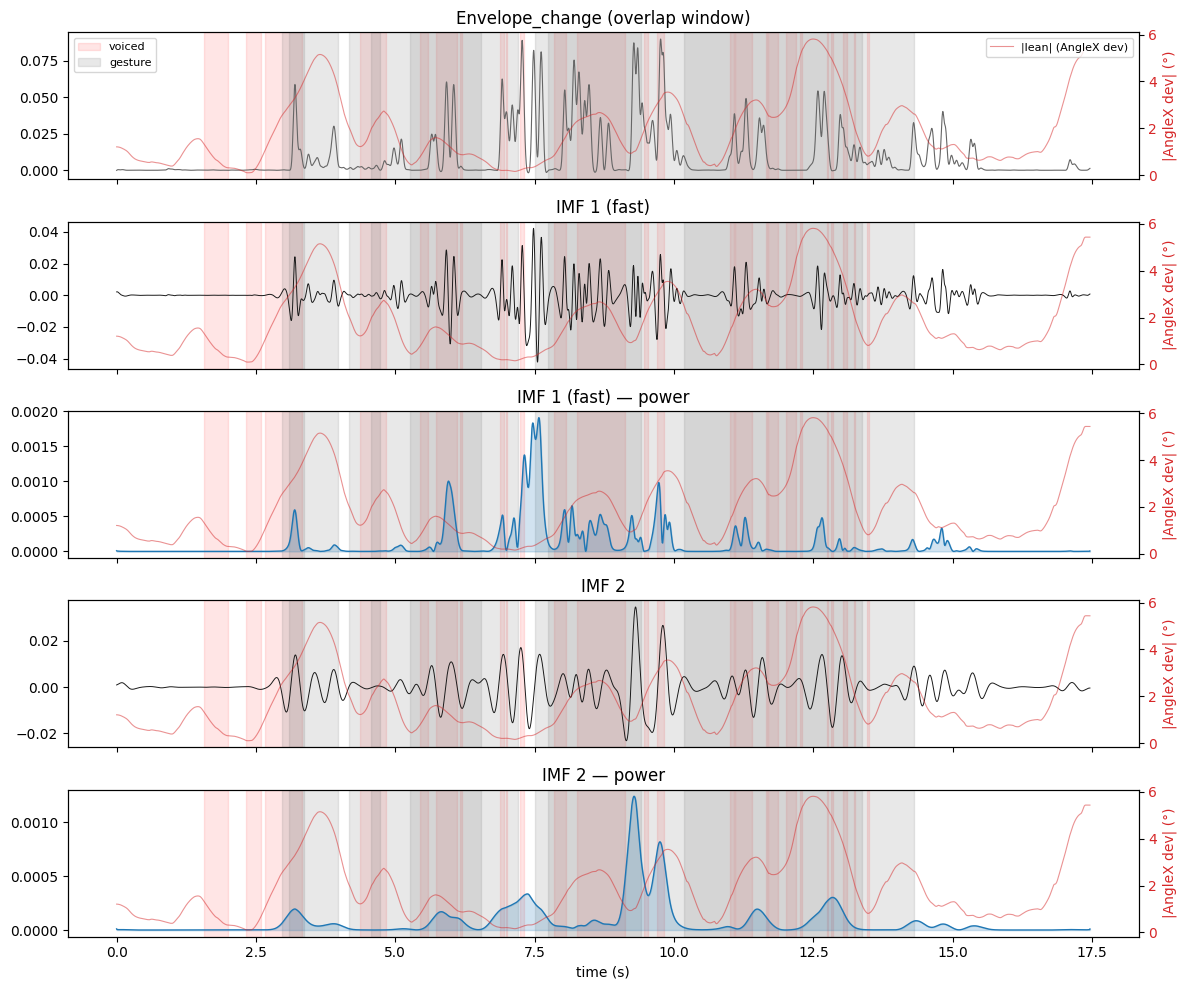

In [120]:
import emd
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

time, sig, sway_speed, sway_lean = align_gyro_to_envelope(
    envtest, gyrotest, column='envelope_change')

imf_env = emd.sift.mask_sift(sig, max_imfs=2)
amp = np.abs(hilbert(imf_env, axis=0))
pwr = amp ** 2

# gesture windows for THIS trial
gtrial = gest[(gest['pair'] == pair) & (gest['trial'] == int(trail_number))].copy()
spans = gtrial['gesture_id'].str.extract(r'_Gesture_([\d.]+)_([\d.]+)$').astype(float)

# voiced windows for THIS trial (from the voicing object built earlier)
vspans = voicing[(voicing['pair'] == pair) & (voicing['trial'] == int(trail_number))]
print(f"{len(spans)} gestures, {len(vspans)} voiced segments (trial ends {time[-1]:.1f}s)")

def overlay_lean(a, show_label=False):
    ab = a.twinx()
    ab.plot(time, sway_lean, color='C3', lw=0.8, alpha=0.5, label='|lean| (AngleX dev)')
    ab.set_ylabel('|AngleX dev| (°)', color='C3'); ab.tick_params(axis='y', labelcolor='C3')
    if show_label:
        ab.legend(loc='upper right', fontsize=8)
    return ab

def mark_gestures(a, label=False):
    for i, (onset, offset) in enumerate(spans.itertuples(index=False)):
        a.axvspan(onset, offset, color='0.5', alpha=0.18, zorder=0,
                  label='gesture' if (label and i == 0) else None)

def mark_voiced(a, label=False):
    for i, (on, off) in enumerate(vspans[['onset','offset']].itertuples(index=False)):
        a.axvspan(on, off, color='red', alpha=0.10, zorder=0,
                  label='voiced' if (label and i == 0) else None)

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

ax[0].plot(time, sig, color='0.4', lw=0.8)
ax[0].set_title('Envelope_change (overlap window)')
mark_voiced(ax[0], label=True); mark_gestures(ax[0], label=True); overlay_lean(ax[0], show_label=True)
ax[0].legend(loc='upper left', fontsize=8)

for k, name in [(0, 'IMF 1 (fast)'), (1, 'IMF 2')]:
    a_imf = ax[1 + 2 * k]
    a_imf.plot(time, imf_env[:, k], color='0.1', lw=0.7)
    a_imf.set_title(name)
    mark_voiced(a_imf); mark_gestures(a_imf); overlay_lean(a_imf)

    a_pwr = ax[2 + 2 * k]
    a_pwr.plot(time, pwr[:, k], 'C0', lw=1.0)
    a_pwr.fill_between(time, pwr[:, k], color='C0', alpha=0.2)
    a_pwr.set_title(f'{name} — power')
    mark_voiced(a_pwr); mark_gestures(a_pwr); overlay_lean(a_pwr)

ax[-1].set_xlabel('time (s)')
plt.tight_layout()

# role out with surrogate analysis (using multisyncpy)

OK now we have comparable timescales. Lets assess coupling between the two signals. We will use the `multisyncpy` for surrogate coupling analysis.

We assess whether the coupling of IMF1 powerseries-lean and IMF2 powerseries-lean is reliable in either conditionbalance, and we also assess within each of these with surrogate analysis.

In [102]:
import numpy as np, pandas as pd, os, emd
from scipy.signal import hilbert
from scipy.stats import spearmanr

INTERMEDIATE = './intermediateoutput'
os.makedirs(INTERMEDIATE, exist_ok=True)

gyro_all = pd.read_csv('../../gyroscope.csv')
meta_all = pd.read_csv('../../metadata.csv')

def iaaft(x, n_iter=100, rng=None):
    """One IAAFT surrogate of a CONTINUOUS series: preserves power spectrum + amplitude dist."""
    rng = rng or np.random.default_rng()
    n = len(x)
    amp_sorted = np.sort(x)
    fft_mag = np.abs(np.fft.rfft(x))
    surr = rng.permutation(x)
    for _ in range(n_iter):
        phases = np.angle(np.fft.rfft(surr))
        surr = np.fft.irfft(fft_mag * np.exp(1j * phases), n=n)
        surr = amp_sorted[np.argsort(np.argsort(surr))]
    return surr

def get_surrogates(lean, pair, trial, n_surrogates=200, n_iter=100):
    """n_surrogates IAAFT surrogates of the full lean, cached per trial. Regenerates if shape mismatches."""
    path = os.path.join(INTERMEDIATE, f'iaaft_{pair}_{trial}_n{n_surrogates}.npy')
    if os.path.exists(path):
        surr = np.load(path)
        if surr.shape == (n_surrogates, len(lean)):
            return surr
    seed = int(''.join(filter(str.isdigit, f'{pair}{trial}'))) % (2**32)
    rng = np.random.default_rng(seed)
    surr = np.array([iaaft(lean, n_iter=n_iter, rng=rng) for _ in range(n_surrogates)]).astype(np.float32)
    np.save(path, surr)
    return surr

def masked_rho(x_full, lean_full, surr, mask):
    """Observed rho on masked frames; null from pre-generated surrogates, masked identically."""
    if mask.sum() < 20:
        return np.nan, np.nan, np.nan
    rho, _ = spearmanr(x_full[mask], lean_full[mask])
    null = np.array([spearmanr(x_full[mask], s[mask])[0] for s in surr])
    p = (np.sum(np.abs(null) >= abs(rho)) + 1) / (len(surr) + 1)
    return rho, p, null.mean()

def _mask_from_spans(spans, time):
    m = np.zeros(len(time), dtype=bool)
    for on, off in spans[['onset', 'offset']].itertuples(index=False):
        m |= (time >= on) & (time <= off)
    return m

def analyse_trial(env_path, fs=500.0, n_surrogates=50):
    name = os.path.basename(env_path.replace('\\', '/'))
    parts = name.split('_')
    pair, trial = f"{parts[1]}_{parts[2]}", int(parts[3])

    envtest = pd.read_csv(env_path)
    gyrotest = gyro_all[(gyro_all['group_name'] == pair) &
                        (gyro_all['trial_number'] == trial)]
    if len(gyrotest) < 50:
        return None

    meta = meta_all[(meta_all['pair_id'] == pair) & (meta_all['trial_number'] == trial)]
    condition = meta['clue_giver_condition'].iloc[0] if len(meta) else np.nan

    time, env_clip, sway_speed, sway_lean = align_gyro_to_envelope(
        envtest, gyrotest, column='envelope_change', fs=fs)

    edge = int(1.0 * fs)
    if len(env_clip) <= 2 * edge:
        return None

    imf = emd.sift.mask_sift(env_clip, max_imfs=2)
    _, inst_freq, inst_amp = emd.spectra.frequency_transform(imf, fs, 'hilbert')
    mean_freq = np.sum(inst_freq * inst_amp**2, 0) / np.sum(inst_amp**2, 0)
    pwr = np.abs(hilbert(imf, axis=0)) ** 2

    lean = sway_lean[edge:-edge]
    t    = time[edge:-edge]

    surr = get_surrogates(lean, pair, trial, n_surrogates)   # generate/load ONCE per trial

    vspan = voicing[(voicing['pair'] == pair) & (voicing['trial'] == trial)]
    gspan = gest[(gest['pair'] == pair) & (gest['trial'] == trial)]
    gspan = gspan['gesture_id'].str.extract(r'_Gesture_([\d.]+)_([\d.]+)$').astype(float) \
                               .rename(columns={0: 'onset', 1: 'offset'})
    voiced  = _mask_from_spans(vspan, t)
    gesture = _mask_from_spans(gspan, t)
    full    = np.ones(len(t), dtype=bool)

    row = dict(pair=pair, trial=trial, condition=condition, n=len(lean),
               frac_voiced=voiced.mean(), frac_gesture=gesture.mean())
    masks = {'': full, '_voiced': voiced, '_unvoiced': ~voiced,
             '_gest': gesture, '_still': ~gesture}

    for k in range(2):
        x = pwr[edge:-edge, k]
        row[f'mf_imf{k+1}'] = mean_freq[k]
        for suf, m in masks.items():
            rho, p, sm = masked_rho(x, lean, surr, m)
            row[f'rho{suf}_imf{k+1}']  = rho
            row[f'p{suf}_imf{k+1}']    = p
            row[f'surr{suf}_imf{k+1}'] = sm
    return row

results = pd.DataFrame([r for f in envelopes if (r := analyse_trial(f)) is not None])
print(f"{len(results)} trials | conditions: {results['condition'].value_counts().to_dict()}")
print(f"voiced {results['frac_voiced'].median():.0%}, gesture {results['frac_gesture'].median():.0%} of trial (median)")
results.head()

C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
C:\Users\Admin\AppData\Roaming\Pytho

80 trials | conditions: {'board': 40, 'ground': 40}
voiced 36%, gesture 66% of trial (median)


,pair,trial,condition,n,frac_voiced,frac_gesture,mf_imf1,rho_imf1,p_imf1,surr_imf1,...,surr_voiced_imf2,rho_unvoiced_imf2,p_unvoiced_imf2,surr_unvoiced_imf2,rho_gest_imf2,p_gest_imf2,surr_gest_imf2,rho_still_imf2,p_still_imf2,surr_still_imf2
0,103_203,12,board,7666,0.336421,0.693712,5.632290,-0.126354,0.705882,0.008169,...,0.030001,0.048459,0.882353,0.028402,0.001336,0.960784,-0.010743,-0.188287,0.647059,0.056366
1,103_203,13,board,7731,0.356746,0.555685,6.474885,0.255099,0.117647,0.022633,...,-0.003200,0.333684,0.098039,0.035211,0.523443,0.058824,-0.002751,0.009936,1.000000,0.047973
2,103_203,14,board,9992,0.439652,0.957066,6.473328,-0.303627,0.137255,-0.001612,...,-0.002130,-0.181442,0.411765,-0.029044,-0.353886,0.058824,-0.009666,-0.748351,0.313725,0.047245
3,103_203,15,board,9201,0.407564,1.000000,6.224960,-0.085000,0.529412,0.021704,...,0.011471,-0.090289,0.686275,0.012973,-0.025017,0.882353,0.015225,NaN,NaN,NaN
4,103_203,16,board,6687,0.288321,0.891132,6.883708,0.260392,0.372549,0.005010,...,-0.020674,0.349082,0.215686,0.026587,0.312636,0.274510,0.005185,-0.930091,0.176471,0.094810


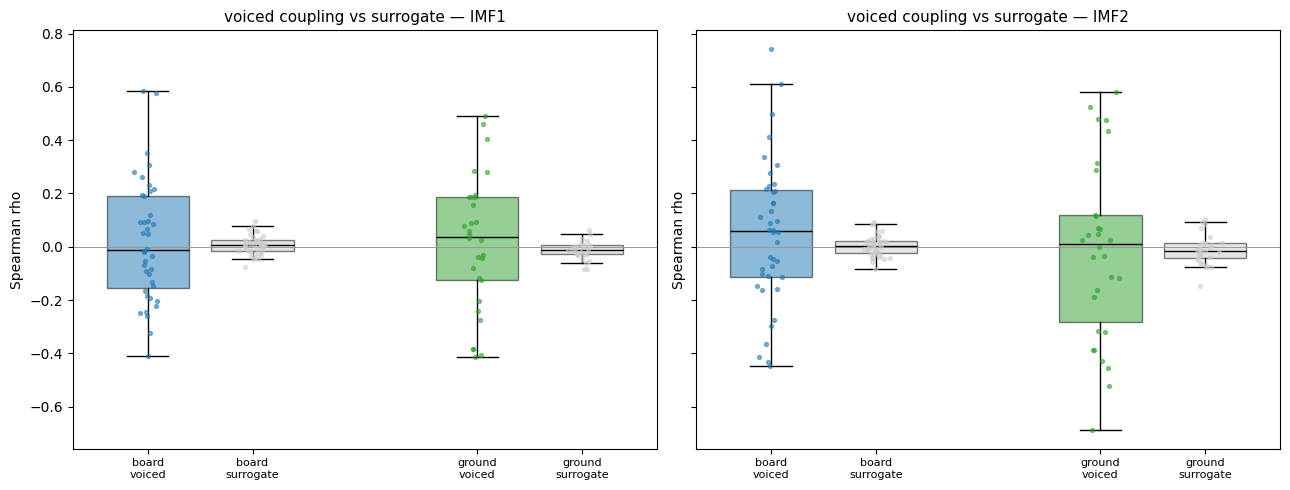

In [111]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
conds = sorted(results['condition'].dropna().unique())
cond_colors = dict(zip(conds, ['C0', 'C2']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, imf in zip(axes, [1, 2]):
    groups, labels, facecolors, positions, pos = [], [], [], [], 0
    for cond in conds:
        sub = results[results['condition'] == cond]
        obs = sub[f'rho_voiced_imf{imf}'].to_numpy();  obs = obs[np.isfinite(obs)]
        sur = sub[f'surr_voiced_imf{imf}'].to_numpy(); sur = sur[np.isfinite(sur)]
        groups += [obs, sur]
        positions += [pos, pos + 0.7]
        labels += [f'{cond}\nvoiced', f'{cond}\nsurrogate']
        facecolors += [cond_colors[cond], '0.8']
        pos += 2.2

    bp = ax.boxplot(groups, positions=positions, widths=0.55, showfliers=False,
                    patch_artist=True, medianprops=dict(color='k'))
    for patch, fc in zip(bp['boxes'], facecolors):
        patch.set_facecolor(fc); patch.set_alpha(0.5)
    for i, (vals, fc) in enumerate(zip(groups, facecolors)):
        ax.scatter(rng.normal(positions[i], 0.04, len(vals)), vals, s=8, color=fc, alpha=0.55, zorder=3)

    ax.axhline(0, color='0.6', lw=0.7)
    ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'voiced coupling vs surrogate — IMF{imf}', fontsize=11)
    ax.set_ylabel('Spearman rho')

plt.tight_layout()

In [112]:
import pandas as pd, numpy as np
from scipy.stats import spearmanr

kin = ['duration','hold_time','hand_submovements',
       'hand_mean_submovement_amplitude','hand_peak_speed','hand_mean_speed',
       'hand_peak_acceleration','hand_peak_jerk','elbow_peak_speed',
       'elbow_mean_speed','elbow_peak_jerk','space_use']
per_trial = gest.groupby(['pair','trial'])[kin].mean().reset_index()   # mean kinematic per trial
per_trial['n_gestures'] = gest.groupby(['pair','trial']).size().values
per_trial['n_gestureduration'] = gest.groupby(['pair','trial'])['duration'].sum().values
merged = results.merge(per_trial, on=['pair','trial'], how='inner')

# coupling STRENGTH on voiced frames (matches the masked analysis)
merged['abs_voiced_imf1'] = merged['rho_voiced_imf1'].abs()
merged['abs_voiced_imf2'] = merged['rho_voiced_imf2'].abs()

rows = []
for cond, sub in merged.groupby('condition'):
    for f in kin + ['n_gestures', 'n_gestureduration']:
        for target in ['abs_voiced_imf1','abs_voiced_imf2']:
            d = sub[[f, target]].dropna()
            if len(d) > 5:
                r, p = spearmanr(d[f], d[target])
                rows.append((cond, f, target, r, p, len(d)))
scan = pd.DataFrame(rows, columns=['condition','feature','target','r','p','n']).sort_values('p')
print(scan.head(20).to_string(index=False))

condition                         feature          target         r        p  n
    board                 hand_peak_speed abs_voiced_imf2  0.422065 0.007442 39
    board          hand_peak_acceleration abs_voiced_imf2  0.400810 0.011451 39
    board hand_mean_submovement_amplitude abs_voiced_imf2  0.394332 0.012989 39
    board                  hand_peak_jerk abs_voiced_imf2  0.389271 0.014310 39
   ground                       space_use abs_voiced_imf1 -0.472748 0.014732 26
   ground                      n_gestures abs_voiced_imf1 -0.445823 0.022449 26
   ground               n_gestureduration abs_voiced_imf1 -0.440684 0.024242 26
    board               n_gestureduration abs_voiced_imf1 -0.349798 0.029044 39
    board                elbow_peak_speed abs_voiced_imf2  0.345951 0.030984 39
    board                 hand_mean_speed abs_voiced_imf2  0.330162 0.040098 39
    board                 elbow_peak_jerk abs_voiced_imf2  0.300000 0.063519 39
    board                      n_gesture

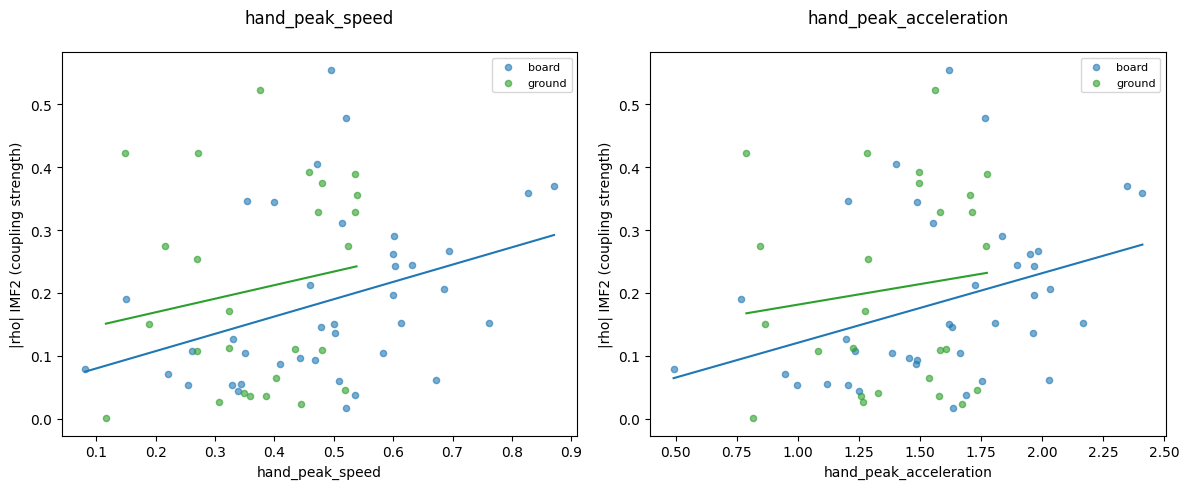

In [118]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

conds = sorted(merged['condition'].dropna().unique())
colors = dict(zip(conds, ['C0', 'C2']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat in zip(axes, ['hand_peak_speed', 'hand_peak_acceleration']):
    notes = []
    for cond in conds:
        d = merged[merged['condition'] == cond][[feat, 'abs_voiced_imf2']].dropna()
        x, y = d[feat].to_numpy(), d['abs_voiced_imf2'].to_numpy()
        # log-transform the feature if it's skewed (e.g., jerk, space use)
        x, y = np.log1p(x), np.log1p(y)  # log1p to handle zero values
        if len(x) < 5:
            continue
        r, p = spearmanr(x, y)
        ax.scatter(x, y, s=20, alpha=0.6, color=colors[cond], label=cond)
        b, a = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, a + b * xs, color=colors[cond], lw=1.5)
    ax.set_xlabel(feat); ax.set_ylabel('|rho| IMF2 (coupling strength)')
    ax.set_title(f'{feat}\n' + '   '.join(notes))
    ax.legend(fontsize=8)
plt.tight_layout()